In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Load the data
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.shape

(119390, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.drop(columns=['company'], inplace=True) # It has lots of missing values not direct related to our analysis

In [ ]:
df['children'] = df['children'].fillna(0)

In [ ]:
df['agent'] = df['agent'].fillna(0)

In [ ]:
df.dropna(subset=['country'], inplace=True)

In [ ]:
df.shape

(118902, 31)

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.duplicated().sum()

np.int64(31965)

In [ ]:
df[df.duplicated()].head(10) # No need to drop duplicate values they seem genuine separate bookings.

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,1,No Deposit,250.0,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,0,No Deposit,250.0,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,0,No Deposit,240.0,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,0,No Deposit,240.0,0,Transient,109.80,0,3,Check-Out,2015-07-08
219,Resort Hotel,1,1,2015,July,28,8,0,1,2,...,0,No Deposit,0.0,0,Transient,104.72,0,1,Canceled,2015-07-08
256,Resort Hotel,0,91,2015,July,28,10,0,2,2,...,0,No Deposit,240.0,0,Transient,73.80,0,1,Check-Out,2015-07-12
261,Resort Hotel,0,30,2015,July,28,10,2,2,2,...,0,No Deposit,0.0,0,Transient-Party,197.00,0,1,Check-Out,2015-07-14
353,Resort Hotel,0,98,2015,July,29,13,1,1,2,...,0,No Deposit,240.0,0,Transient-Party,82.00,0,3,Check-Out,2015-07-15
372,Resort Hotel,0,40,2015,July,29,13,1,4,2,...,0,No Deposit,250.0,0,Transient,120.00,0,2,Check-Out,2015-07-18


In [ ]:
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"])

In [ ]:
df['reservation_status_date'].dtypes

dtype('<M8[ns]')

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902
mean,0.371373,104.308027,2016.157617,27.166726,15.800567,0.928891,2.502136,1.858404,0.104203,0.007948,0.032010,0.087139,0.131629,0.221174,74.893938,2.330676,102.000808,0.061883,0.571706,2016-07-30 07:20:24.584952064
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483174,106.903127,0.707479,13.589774,8.780371,0.996211,1.900165,0.578576,0.399166,0.097379,0.176026,0.845855,1.484647,0.652775,107.144715,17.630161,50.487004,0.244168,0.792678,NaN


In [ ]:
df['adr'].min()

-6.38

In [ ]:
df['adults'].max()

55

In [ ]:
df['adults'].value_counts().sort_index(ascending=False).head(10)

,count
adults,
55,1
50,1
40,1
27,2
26,5
20,2
10,1
6,1
5,2


In [ ]:
df = df[df['adults'] > 0]
df = df[df['adults'] <= 4]
df = df[df['adr'] > 0]

In [ ]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [ ]:
df.shape

(116715, 32)

In [ ]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,72843
1,43872


In [ ]:
cancellation_rate = 43872 / (72843 + 43872) * 100
cancellation_rate

37.58899884333633

**Insight 1**

Out of 116,715 bookings, 37.5% were cancelled — indicating cancellations are a significant revenue risk for the hotel.

In [ ]:
df['hotel'].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [ ]:
df.groupby('hotel')['is_canceled'].mean()

,is_canceled
hotel,
City Hotel,0.422263
Resort Hotel,0.282968


**Insight 2**

City Hotel has a significantly higher cancellation rate (42.2%) compared to Resort Hotel (28.3%) — indicating City Hotel bookings are more prone to cancellation, possibly due to business travel flexibility or different booking patterns.

In [ ]:
df.groupby('is_canceled')['lead_time'].mean()

,lead_time
is_canceled,
0,81.327966
1,145.211091


**Insight 3**

Cancelled bookings have an average lead time of 145 days, almost double the 81 days for non-cancelled bookings — indicating that bookings made far in advance are significantly more likely to be cancelled, possibly because plans change over longer time horizons

In [ ]:
df.groupby('deposit_type')['is_canceled'].mean()

,is_canceled
deposit_type,
No Deposit,0.287860
Non Refund,0.993618
Refundable,0.222222


**Insight 4**

The 99% cancellation rate for Non Refund bookings is unusually high and doesn't match expected behavior. This is likely because the 'cancelled' label in this dataset also includes failed/incomplete bookings (like payment failures), not just genuine guest cancellations — so this number should be interpreted with caution rather than taken at face value.

In [ ]:
df['deposit_type'].value_counts()

,count
deposit_type,
No Deposit,101980
Non Refund,14573
Refundable,162


In [ ]:
df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)

,is_canceled
market_segment,
Undefined,1.000000
Groups,0.617450
Online TA,0.369783
Offline TA/TO,0.345813
Aviation,0.220779
Corporate,0.193523
Direct,0.154610
Complementary,0.080645


**Insight 5**

Groups have the highest cancellation rate (61.7%) among all market segments, followed by Online TA (37%) and Offline TA/TO (34.6%). Direct bookings (15.5%) and Corporate (19.4%) show much lower cancellation rates — direct, personal bookings are more committed than group/agency bookings

In [ ]:
df['market_segment'].value_counts()

,count
market_segment,
Online TA,55830
Offline TA/TO,23825
Groups,19553
Direct,12179
Corporate,5033
Aviation,231
Complementary,62
Undefined,2


In [ ]:
df.groupby('arrival_date_month')['is_canceled'].mean().sort_values(ascending=False)

,is_canceled
arrival_date_month,
June,0.418697
April,0.412046
May,0.401641
September,0.395164
October,0.386154
August,0.382030
July,0.378833
December,0.360863
February,0.340214


**Insight 6**

Cancellation rates are highest during peak travel months — June (41.9%), April (41.2%), and May (40.2%) — likely corresponding to summer holiday season bookings where plans change more often. Winter months (January, November) show the lowest cancellation rates (~31-32%), possibly due to more committed/planned trips.

In [ ]:
df.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False)

,is_canceled
customer_type,
Transient,0.413942
Contract,0.311281
Transient-Party,0.257302
Group,0.078212


**Insight 7**

Transient (individual, non-group) customers have the highest cancellation rate (41.4%), while Group customer type has the lowest (7.8%) — interestingly opposite to the market_segment finding where 'Groups' segment had high cancellation. This suggests 'customer_type: Group' and 'market_segment: Groups' represent different booking categories and shouldn't be confused

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


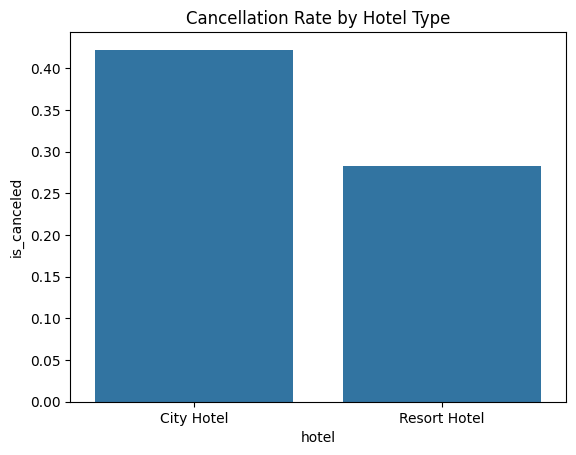

In [ ]:
hotel_cancel = df.groupby('hotel')['is_canceled'].mean().reset_index()
sns.barplot(x='hotel', y='is_canceled', data=hotel_cancel)
plt.title('Cancellation Rate by Hotel Type')
plt.show()

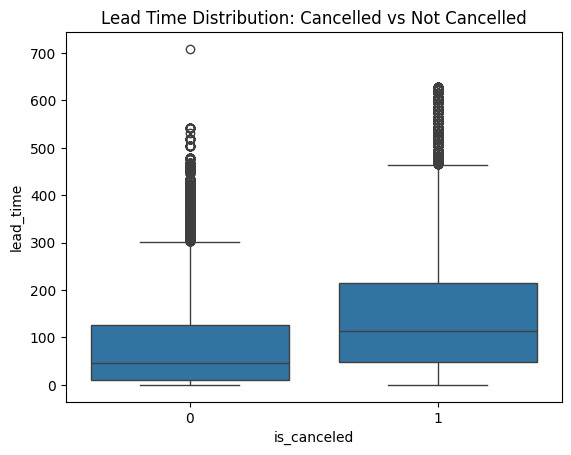

In [ ]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time Distribution: Cancelled vs Not Cancelled')
plt.show()

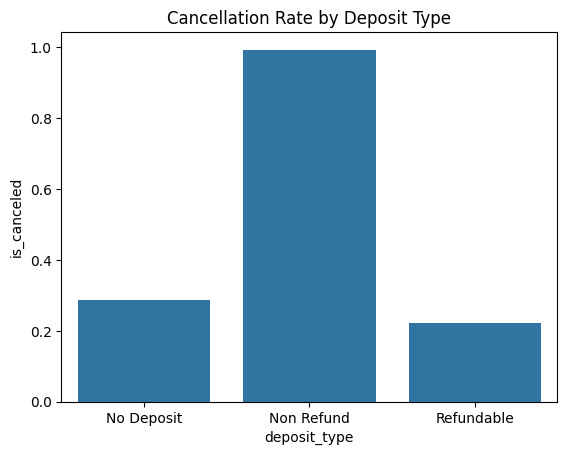

In [ ]:
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean().reset_index()
sns.barplot(x='deposit_type', y='is_canceled', data=deposit_cancel)
plt.title('Cancellation Rate by Deposit Type')
plt.show()

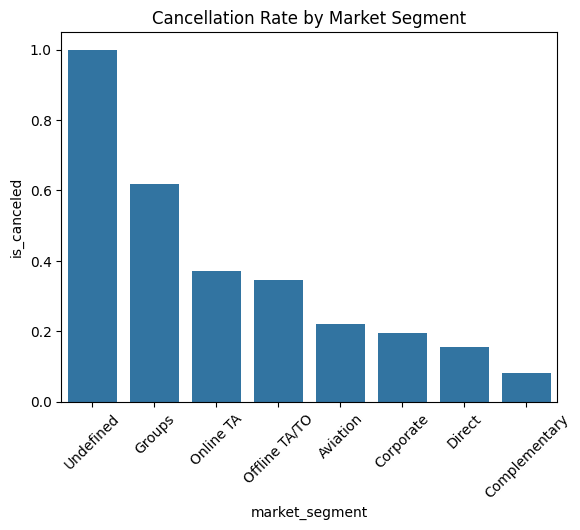

In [ ]:
segment_cancel = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='market_segment', y='is_canceled', data=segment_cancel)
plt.title('Cancellation Rate by Market Segment')
plt.xticks(rotation=45)
plt.show()

In [ ]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_cancel = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order).reset_index()

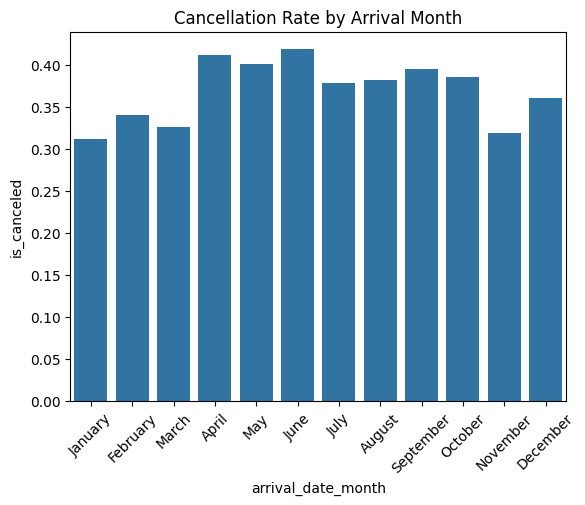

In [ ]:
sns.barplot(x='arrival_date_month', y='is_canceled', data=month_cancel)
plt.title('Cancellation Rate by Arrival Month')
plt.xticks(rotation=45)
plt.show()

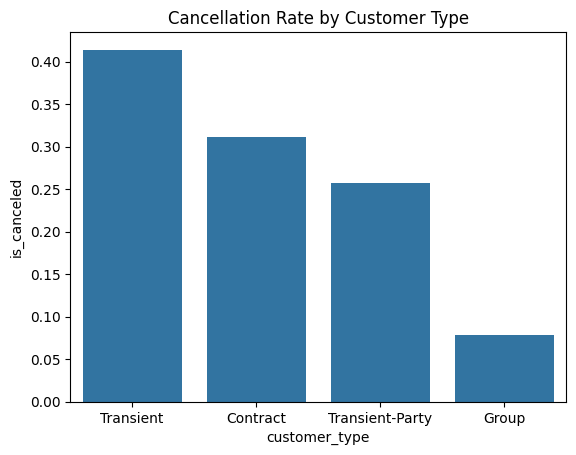

In [ ]:
customer_cancel = df.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='customer_type', y='is_canceled', data=customer_cancel)
plt.title('Cancellation Rate by Customer Type')
plt.show()


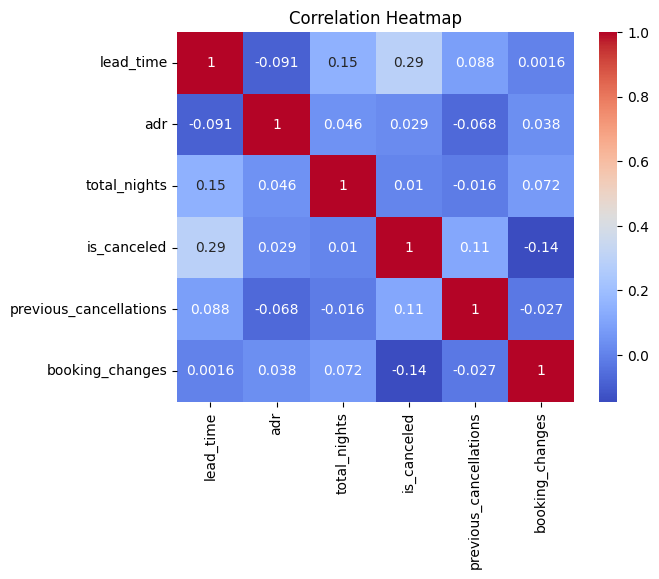

In [ ]:
numeric_cols = ['lead_time', 'adr', 'total_nights', 'is_canceled', 'previous_cancellations', 'booking_changes']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Insight 8**

No single numerical variable shows a strong linear correlation with cancellation (is_canceled) — correlations with lead_time, previous_cancellations, etc. are weak. This suggests cancellation is driven more by categorical factors (deposit type, market segment, customer type, hotel type) and combinations of factors, rather than any single numerical predictor.

## Project Summary

### 1. Objective
To analyze hotel booking data and identify key factors driving cancellations, in order to help the hotel reduce cancellation rates.

### 2. Dataset
116,715 bookings across 32 columns, covering hotel type, lead time, deposit type, market segment, customer type, and arrival dates.

### 3. Key Insights
1. Overall cancellation rate is 37.5% — a significant portion of bookings.
2. City Hotel has a higher cancellation rate (42.2%) than Resort Hotel (28.3%).
3. Cancelled bookings have an average lead time of 145 days vs 81 days for non-cancelled — longer lead time means higher cancellation risk.
4. Non Refund deposit bookings show a 99.4% cancellation rate — likely reflects payment failures/no-shows rather than true cancellations (data quality flag).
5. Groups market segment has the highest cancellation rate (61.7%), while Direct bookings have the lowest (15.5%).
6. Peak season months (June, April, May) show higher cancellation rates than winter months (January, November).
7. Transient (individual) customers cancel more (41.4%) than Group customer type (7.8%).
8. No single numerical variable strongly correlates with cancellation — categorical factors (deposit type, segment, customer type) matter more than numerical ones.

### 4. Recommendations
- **Lead Time**: Send confirmation reminders or require reconfirmation for bookings made far in advance, since longer lead times correlate with higher cancellations.
- **Deposit Type**: Encourage refundable or partial-deposit policies for high-risk segments. The Non Refund spike likely reflects payment/no-show issues rather than genuine cancellations and should be investigated separately.
- **Market Segment**: Incentivize Direct bookings (discounts, loyalty perks) since they show the lowest cancellation rates. Apply stricter cancellation policies for Group and Online TA bookings.

In [ ]:
df.to_csv('hotel_bookings_cleaned.csv', index=False)

In [ ]:
from google.colab import files
files.download('hotel_bookings_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>